In [15]:
import pandas as pd
import glob
import os

# Ambil semua file CSV dari semua subfolder
all_files = glob.glob('data/**/*.csv', recursive = True)
print(f"Total file ditemukan: {len(all_files)}")
print(all_files)

Total file ditemukan: 24
['data\\2024\\2024_aug.csv', 'data\\2024\\2024_des.csv', 'data\\2024\\2024_jul.csv', 'data\\2024\\2024_jun.csv', 'data\\2024\\2024_may.csv', 'data\\2024\\2024_nov.csv', 'data\\2024\\2024_oct.csv', 'data\\2024\\2024_sep.csv', 'data\\2025\\2025_apr.csv', 'data\\2025\\2025_aug.csv', 'data\\2025\\2025_dec.csv', 'data\\2025\\2025_feb.csv', 'data\\2025\\2025_jan.csv', 'data\\2025\\2025_jul.csv', 'data\\2025\\2025_jun.csv', 'data\\2025\\2025_mar.csv', 'data\\2025\\2025_may.csv', 'data\\2025\\2025_nov.csv', 'data\\2025\\2025_oct.csv', 'data\\2025\\2025_sep.csv', 'data\\2026\\2026_apr.csv', 'data\\2026\\2026_feb.csv', 'data\\2026\\2026_jan.csv', 'data\\2026\\2026_mar.csv']


In [21]:
dfs = []

# loop untuk read tiap csv dengan membuang 7 baris pertama dan terakhir
for file in sorted(all_files):
    df_temp = pd.read_csv(file, skiprows=7)
    df_temp = df_temp.iloc[:-7]
    dfs.append(df_temp)

# print(dfs)
df_all = pd.concat(dfs, ignore_index=True)

# # hapus kolom paling kanan
df_all = df_all.drop(columns=df_all.columns[2])
# print(df_all.shape)
# print(df_all.head())

In [25]:
# 8888, 9999 -> NaN
df_all['RR'] = pd.to_numeric(df_all['RR'], errors='coerce')
df_all['RR'] = df_all['RR'].replace([8888, 9999], pd.NA)
print(df_all['RR'].isna().sum())

# NaN -> interpolasi
df_all['RR'] = pd.to_numeric(df_all['RR'], errors='coerce')
df_all['RR'] = df_all['RR'].interpolate(method='linear')
print(df_all['RR'].isna().sum())

62
0


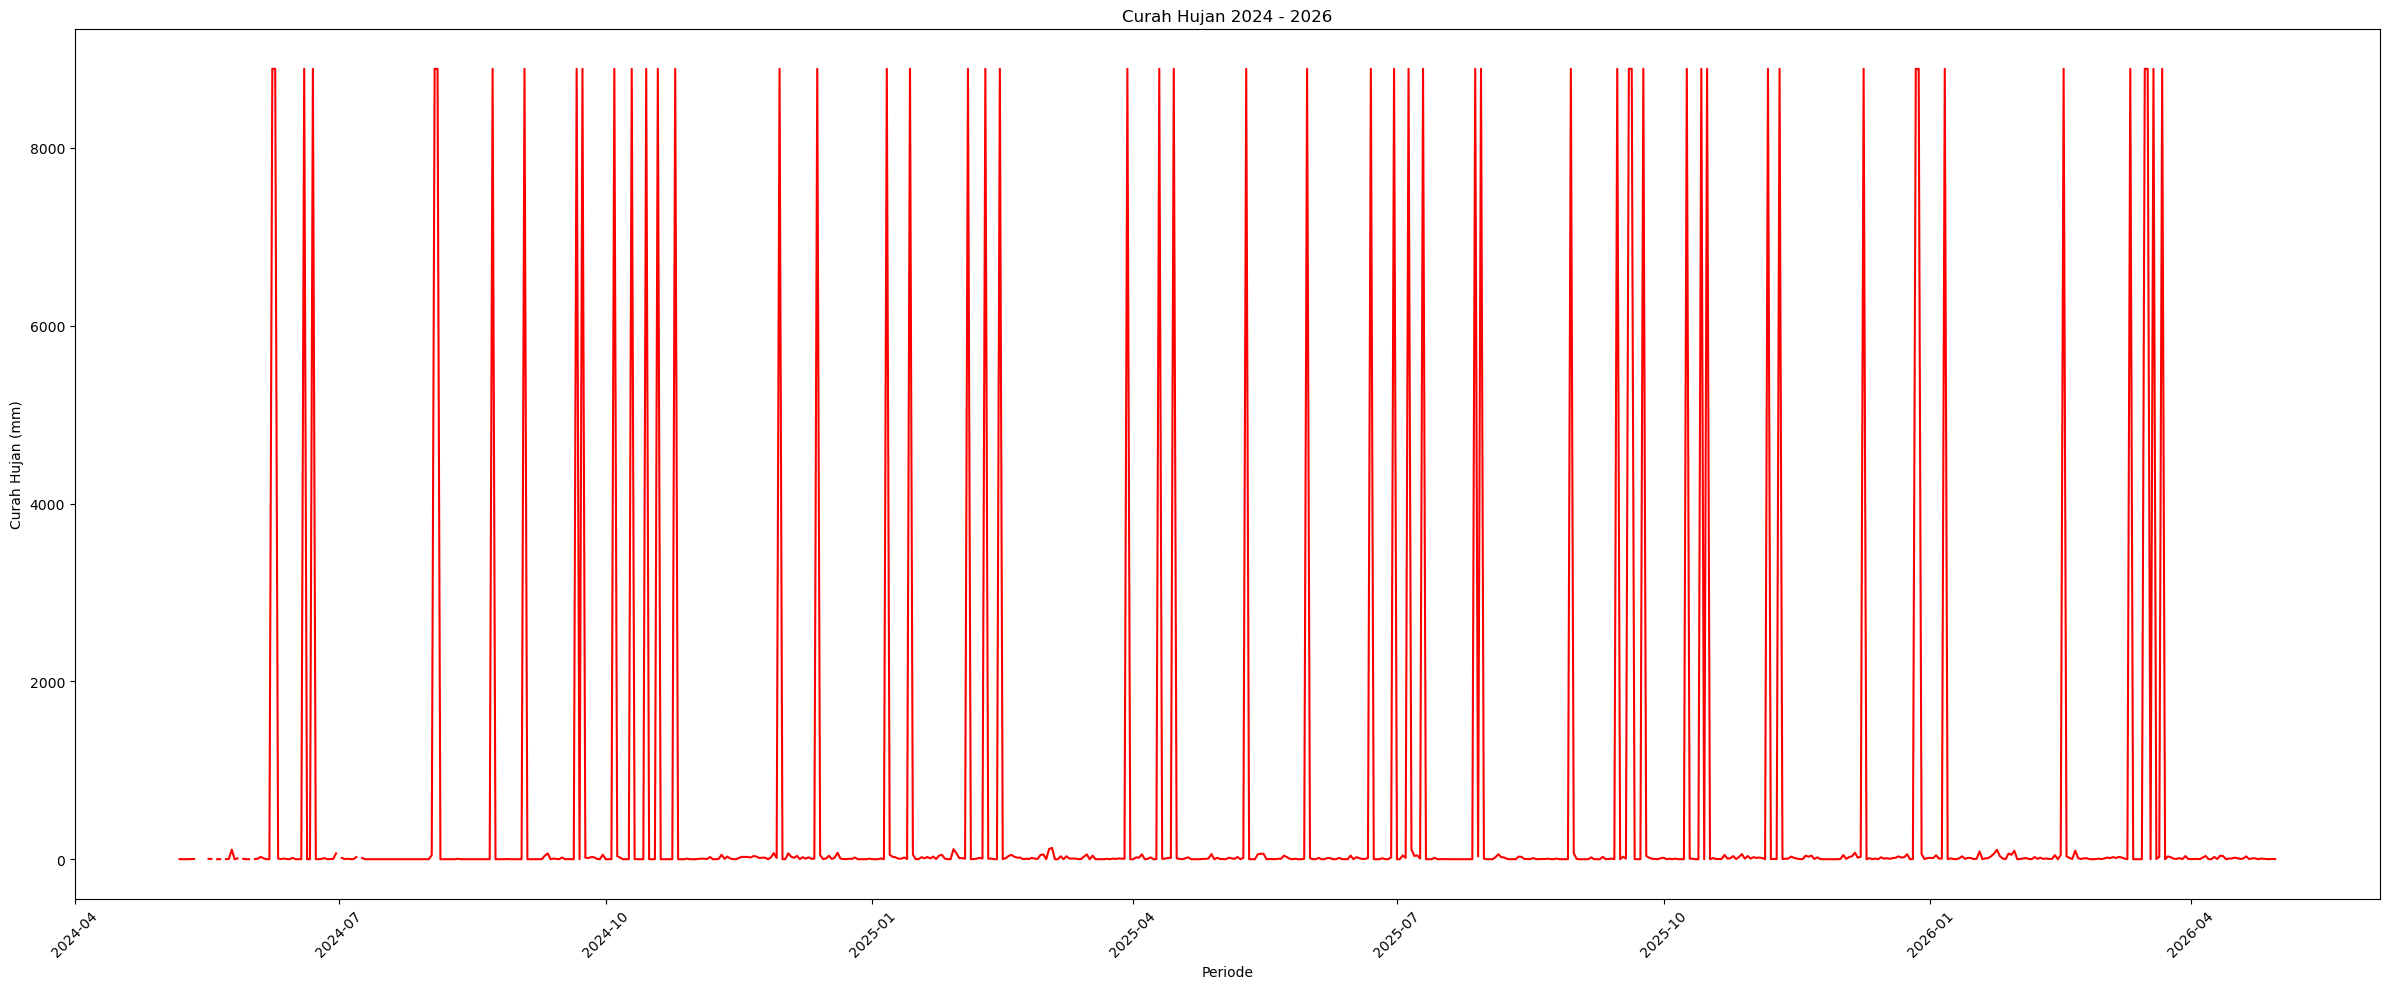

In [14]:
import matplotlib.pyplot as plt

# tanggal -> datetime
df_all['TANGGAL'] = pd.to_datetime(df_all['TANGGAL'], format='%d-%m-%Y')
df_all = df_all.sort_values('TANGGAL').reset_index(drop=True)

plt.figure(figsize=(24, 10))
plt.plot(df_all['TANGGAL'], df_all['RR'], color='red')
plt.title('Curah Hujan 2024 - 2026')
plt.xlabel('Periode')
plt.ylabel('Curah Hujan (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()